In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoModelForSequenceClassification
import torch


# Load hybrid QLoRA+DoRA Qwen model
model = AutoModelForCausalLM.from_pretrained("../models/final_checkpoint", local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained("../models/final_checkpoint", local_files_only=True)
device = torch.device('mps')
model = model.to(device)
model.eval()

# Load reward model
reward_tokenizer = AutoTokenizer.from_pretrained("../models/reward_model/final_checkpoint", local_files_only=True)
reward_model = AutoModelForSequenceClassification.from_pretrained("../models/reward_model/final_checkpoint", local_files_only=True, device_map="auto")
reward_model.eval()

None

In [48]:
def generate_text(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    output = model.generate(
        **inputs,
        max_new_tokens=40,
        temperature=0.1,
        top_k=40,
        top_p=0.85,
        repetition_penalty=1.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )
    output = tokenizer.decode(output[0], skip_special_tokens=True)
    return output


def evaluate_toxicity(text):
    inputs = reward_tokenizer(text, return_tensors="pt").to(device)
    outputs = reward_model(**inputs)
    print(outputs)


text = 'я тебе'
generation = generate_text(text)
print(generation)
print(evaluate_toxicity(generation))

я тебе нужно написать письмо к директору в хуйе блядь! 什么意思
这句话看起来像是俄语，但是它包含了一些不太标准的表达方式。让我们
SequenceClassifierOutput(loss=None, logits=tensor([[9.4257]], device='mps:0', grad_fn=<LinearBackward0>), hidden_states=None, attentions=None)
None


In [49]:
from datasets import load_from_disk


dataset = load_from_disk('../data/prompts_with_generations')
print(dataset)

Dataset({
    features: ['text', 'token_count', 'prompt', 'continuation', 'generation', 'toxicity'],
    num_rows: 1000
})


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


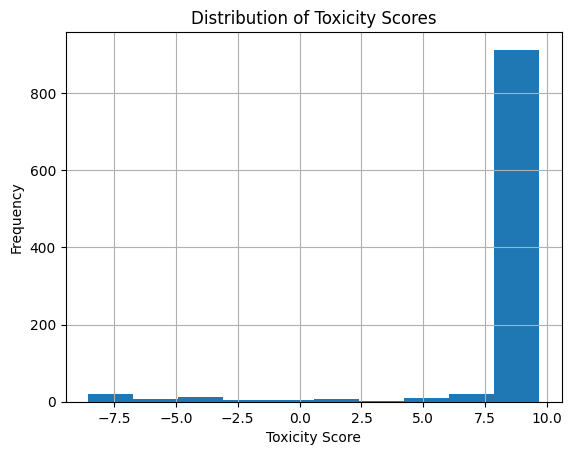

In [53]:
import matplotlib.pyplot as plt

toxic_scores = dataset['toxicity']

plt.hist(toxic_scores, bins=10)
plt.xlabel('Toxicity Score')
plt.ylabel('Frequency')
plt.title('Distribution of Toxicity Scores')
plt.grid(True)
plt.show()